In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

 
#we load the data 
matches    = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')
 
print(matches.info())
print(deliveries.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [101]:
# filling out all the null spaces in datasets
matches['winner']= matches['winner'].fillna('No Result')
matches['player_of_match']= matches['player_of_match'].fillna('N/A')
matches['city']= matches['city'].fillna(matches['venue'])

deliveries = deliveries.drop_duplicates()
matches = matches.drop_duplicates()


In [102]:
matches['date']   = pd.to_datetime(matches['date'], format='%Y-%m-%d')
matches['season'] = matches['date'].dt.year
matches= matches[matches['season'].between(2008, 2025)]
 
std_names = {'Delhi Daredevils': 'Delhi Capitals','Kings XI Punjab': 'Punjab Kings',
    'Deccan Chargers' : 'Sunrisers Hyderabad','Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Pune Warriors': 'Pune Warriors India','Royal Challengers Bangalore':'Royal Challengers Bengaluru'
}
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches[col] = matches[col].replace(std_names)
 
for col in ['batting_team', 'bowling_team']:
    deliveries[col] = deliveries[col].replace(std_names)
 

In [103]:
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('not out')
deliveries['dismissal_kind']   = deliveries['dismissal_kind'].fillna('none')
 
deliveries = deliveries[deliveries['batsman_runs'] <= 6]
deliveries = deliveries[deliveries['total_runs']   <= 9]



In [104]:
matches['id']          = matches['id'].astype(str)
deliveries['match_id'] = deliveries['match_id'].astype(str)
deliveries             = deliveries[deliveries['match_id'].isin(matches['id'].values)]
 
print('Season range :', matches['season'].min(), 'to', matches['season'].max())
print('Total matches:', matches.shape[0])
print('Total balls :', deliveries.shape[0])

Season range : 2008 to 2024
Total matches: 1095
Total balls : 260920


EXPLORATORY DATA ANALYSIS

In [105]:
#analysis 1: team win rates
active_teams = [
    'Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bengaluru',
    'Kolkata Knight Riders', 'Delhi Capitals', 'Punjab Kings',
    'Rajasthan Royals', 'Sunrisers Hyderabad', 'Lucknow Super Giants',
    'Gujarat Titans']

team1        = matches['team1'].value_counts()
team2        = matches['team2'].value_counts()
total_played = (team1.add(team2, fill_value=0)).astype(int)
wins         = matches[matches['winner'] != 'No Result']['winner'].value_counts()
 
winner_data= pd.DataFrame({'wins': wins, 'played': total_played}).dropna()
winner_data['win_rate'] = (winner_data['wins'] / winner_data['played'] * 100).round(1)
winner_data= winner_data[winner_data.index.isin(active_teams)].sort_values('win_rate', ascending=True)

In [106]:
top_batters = (
    deliveries.groupby('batter')['batsman_runs'].sum()
    .reset_index().rename(columns={'batsman_runs': 'total_runs'})
    .query('total_runs >=1000').sort_values('total_runs', ascending=False)
    .head(15)
)
print(top_batters)

             batter  total_runs
631         V Kohli        8014
512        S Dhawan        6769
477       RG Sharma        6630
147       DA Warner        6567
546        SK Raina        5536
374        MS Dhoni        5243
30   AB de Villiers        5181
124        CH Gayle        4997
501      RV Uthappa        4954
282      KD Karthik        4843
289        KL Rahul        4689
50        AM Rahane        4642
188    F du Plessis        4571
572       SV Samson        4419
64        AT Rayudu        4348


In [107]:
top_bowlers=(deliveries[deliveries['player_dismissed']!='not out']
             .groupby('bowler')['player_dismissed']
             .count()
             .reset_index()
             .rename(columns={'player_dismissed':'wickets'})
             .query('wickets>=75')
             .sort_values('wickets',ascending=False)
             .head(10))
print(top_bowlers)

         bowler  wickets
449   YS Chahal      213
104    DJ Bravo      207
301   PP Chawla      201
383   SP Narine      200
308    R Ashwin      198
63      B Kumar      195
376  SL Malinga      188
7      A Mishra      183
171   JJ Bumrah      182
323   RA Jadeja      169


In [108]:
#season trends
matches_per_season = matches.groupby('season').size().reset_index(name='matches')
 
runs_per_match = (
    deliveries.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
    .groupby(['season', 'match_id'])['total_runs']
    .sum()
    .reset_index()
    .groupby('season')['total_runs']
    .mean()
    .reset_index(name='avg_runs')
)
print(runs_per_match)
 

    season    avg_runs
0     2008  309.258621
1     2009  286.894737
2     2010  314.716667
3     2011  289.780822
4     2012  303.418919
5     2013  297.394737
6     2014  315.516667
7     2015  311.067797
8     2016  314.366667
9     2017  318.406780
10    2018  331.683333
11    2019  323.900000
12    2020  323.600000
13    2021  310.616667
14    2022  329.662162
15    2023  347.135135
16    2024  365.788732


In [109]:
#toss impact

toss= matches[matches['winner'] != 'No Result'].copy()
toss['toss_win_match_win'] = toss['toss_winner'] == toss['winner']
overall = toss['toss_win_match_win'].value_counts(normalize=True) * 100
by_decision= toss.groupby('toss_decision')['toss_win_match_win'].mean() * 100

print("probability of winning over a toss win:\n",overall)

probability of winning over a toss win:
 toss_win_match_win
True     50.825688
False    49.174312
Name: proportion, dtype: float64


VISUALISATIONS

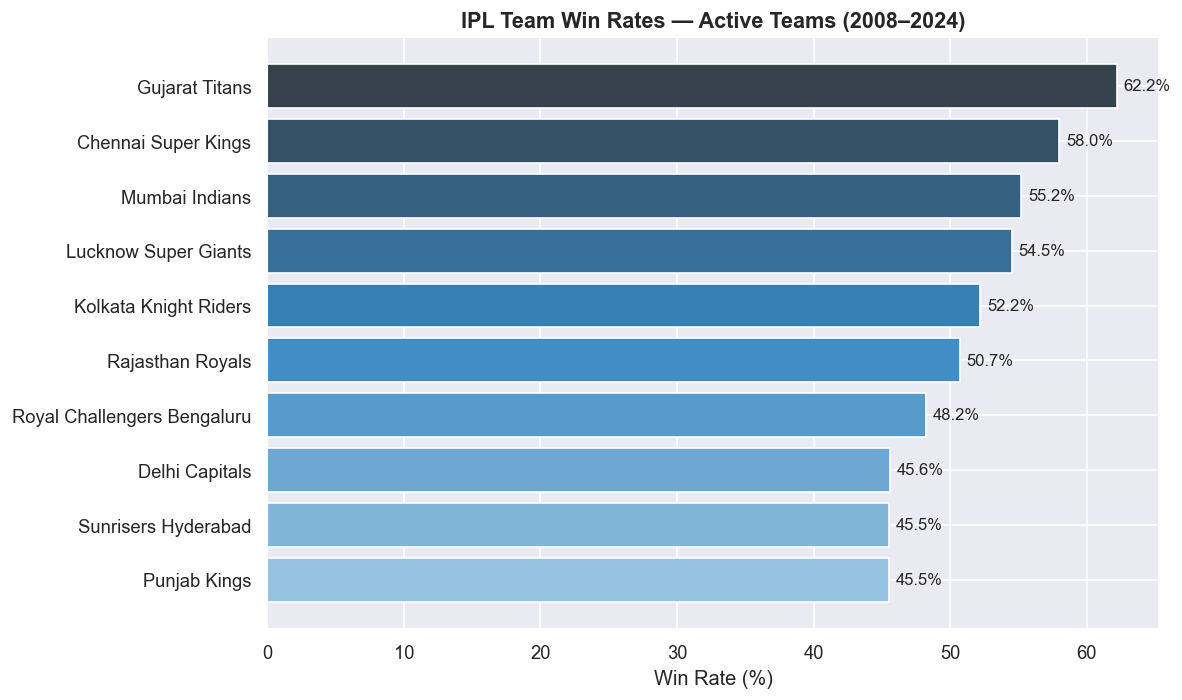

In [110]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(winner_data.index, winner_data['win_rate'],
               color=sns.color_palette('Blues_d', len(winner_data)))

ax.bar_label(bars, labels=[f"{v:.1f}%" for v in winner_data['win_rate']],
             padding=4, fontsize=10)

ax.set_xlabel('Win Rate (%)')
ax.set_title('IPL Team Win Rates — Active Teams (2008–2024)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

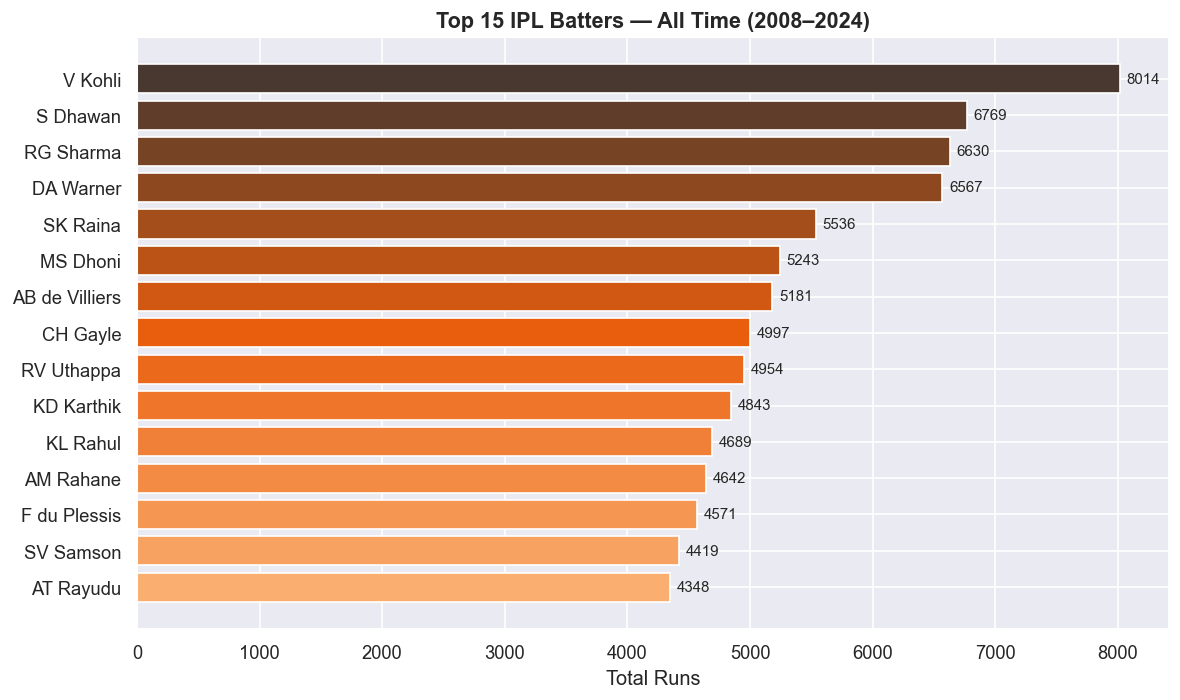

In [111]:
# Plot 2 — Top Batters
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_batters['batter'][::-1], top_batters['total_runs'][::-1], color=sns.color_palette('Oranges_d', 15))
ax.bar_label(bars, padding=4, fontsize=9) 
ax.set_xlabel('Total Runs') 
ax.set_title('Top 15 IPL Batters — All Time (2008–2024)', fontsize=13, fontweight='bold')
plt.tight_layout()

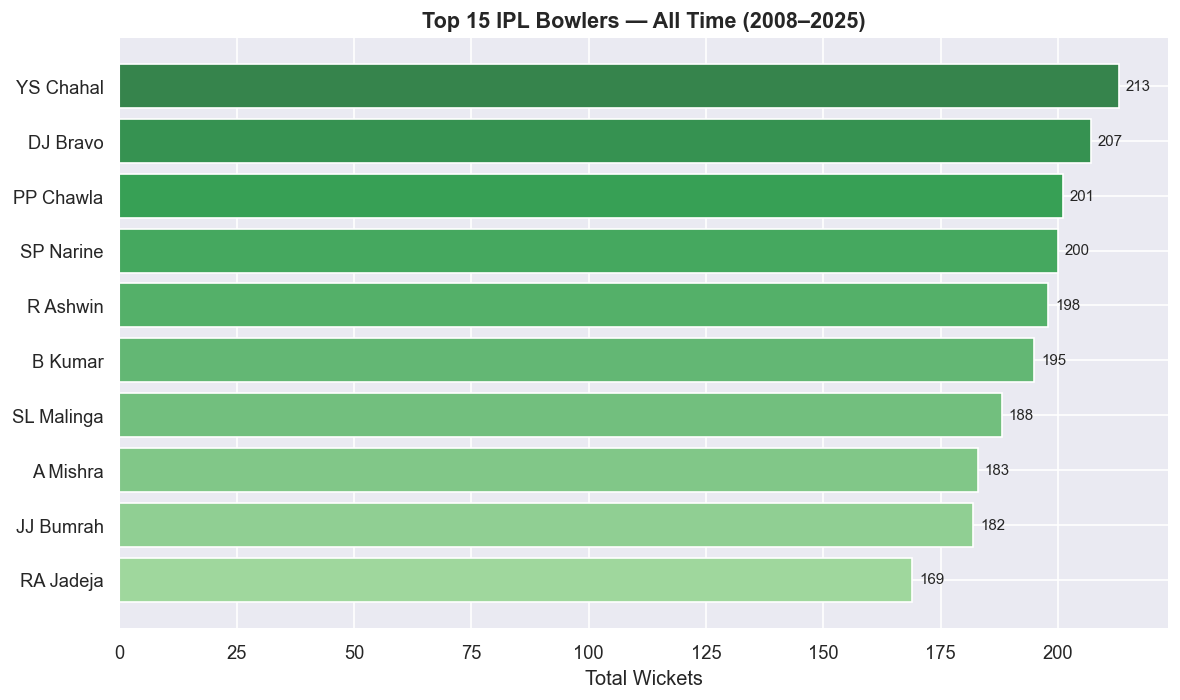

In [112]:
# Plot 3 — Top Bowlers
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_bowlers['bowler'][::-1], top_bowlers['wickets'][::-1],
               color=sns.color_palette('Greens_d', 15))
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Total Wickets')
ax.set_title('Top 15 IPL Bowlers — All Time (2008–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 

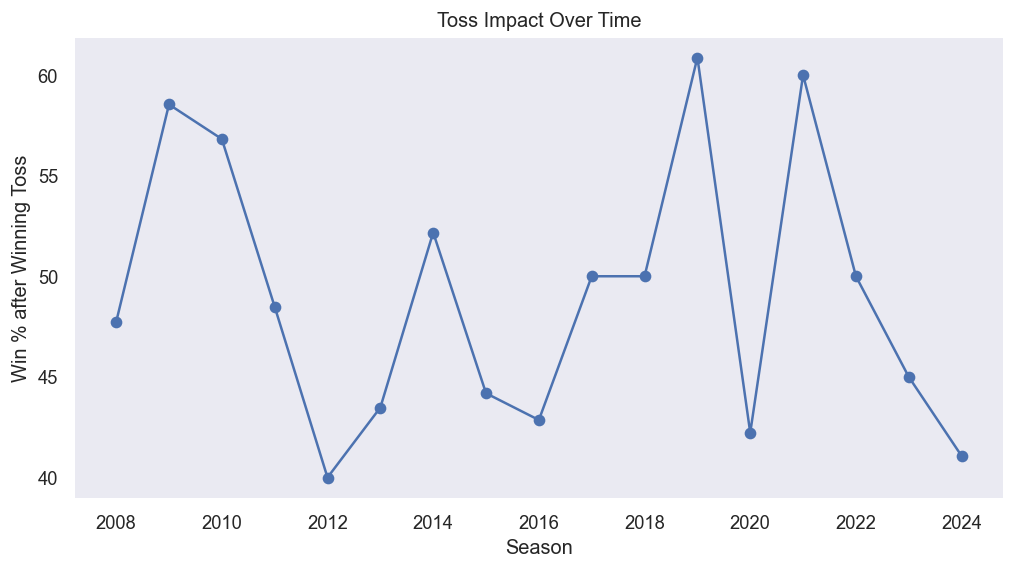

In [113]:
# Plot 4 — Toss Impact 
toss_trend['toss_win_match_win'] = toss_trend['toss_winner'] == toss_trend['winner']

yearly = toss_trend.groupby('season')['toss_win_match_win'].mean() * 100

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values, marker='o')

plt.xlabel("Season")
plt.ylabel("Win % after Winning Toss")
plt.title("Toss Impact Over Time")

plt.grid()
plt.show()

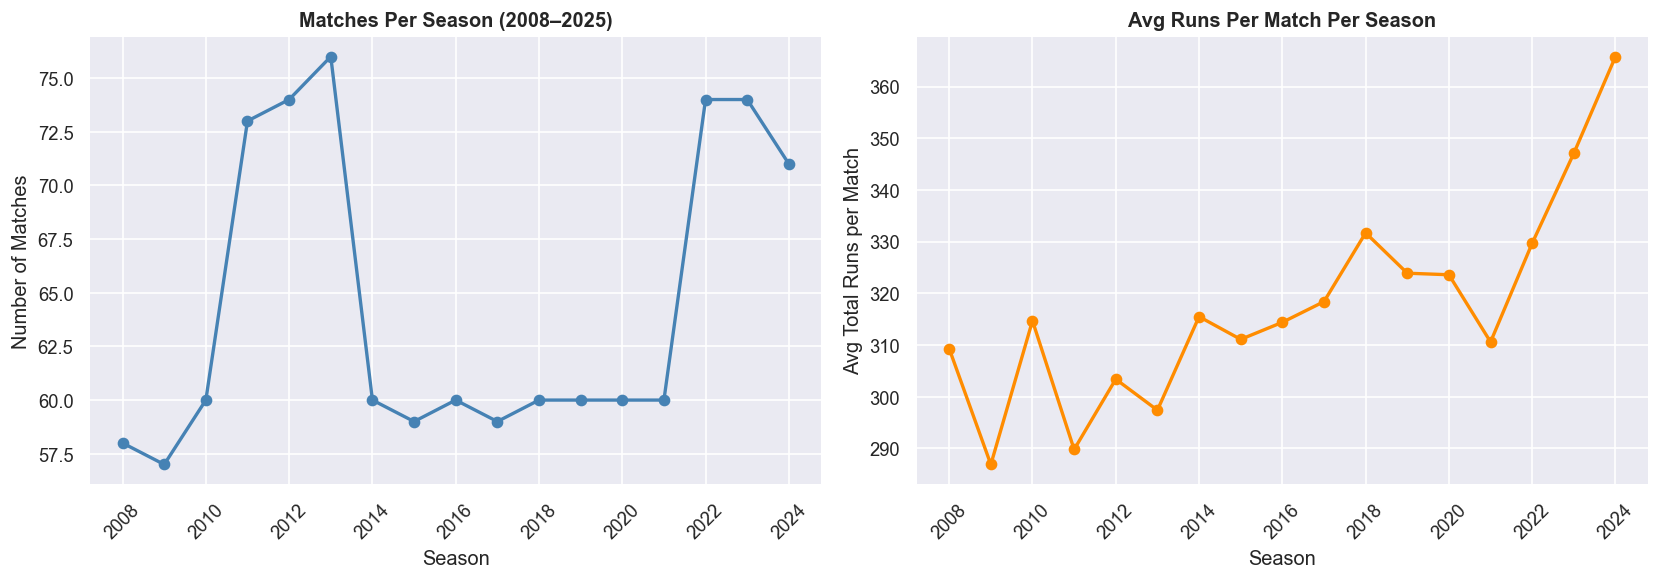

In [114]:
# Plot 5 — Season Trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(matches_per_season['season'], matches_per_season['matches'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Number of Matches')
axes[0].set_title('Matches Per Season (2008–2025)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(runs_per_match['season'], runs_per_match['avg_runs'].round(1),
             marker='o', color='darkorange', linewidth=2)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Avg Total Runs per Match')
axes[1].set_title('Avg Runs Per Match Per Season', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()